## Import Libraries

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step-01: Import the Datasets

In [3]:
df = pd.read_csv('../data/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## step 02 data inspection

In [4]:
#  now i want to inspects the datasets and its related columns and its data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [7]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [8]:
# now i want to know how many unique values in each column
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [9]:
# now i want to check the null values in the datasets
df.isnull().sum() 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## STEP 3: DATA CLEANING

In [10]:
# now i want to check the null values in the datasets
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
# now there is the data claening step in the step 03 in eda process in which there are many methods to handle the null values in the datasets and i will use the fillna method to fill the null values with the mean of the column
# there us 3 columns have missing values in the datasets and they are Age, Cabin and Embarked columns and i will fill the null values in the Age column with the median  of the Age column and i will fill the null values in the Embarked column with the mode of the Embarked column and i will drop the Cabin column because it has a lot of missing values

# fill the null values in the Age column with the median becouse the mediun is robust to the outliers and the mean is not robust to the outliers
df["Age"] = df["Age"].fillna(df["Age"].median(), inplace=True)

# fill the null values in the Embarked column with the mode of the Embarked column
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# drop the Cabin column because it has a lot of missing values which is not useful as beginer 
df.drop("Cabin", axis=1, inplace=True)

C:\Users\PMYLS\AppData\Local\Temp\ipykernel_18764\3268384286.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Age"] = df["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\PMYLS\AppData\Local\Temp\ipykernel_18764\3268384286.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chai

In [12]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Drop Unnecessary Columns

In [13]:
# now drop the unnecessary columns in the datasets which is not useful for the analysis and the columns are PassengerId, Name and Ticket because they are not useful for the analysis and they are not related to the target variable which is Survived column and i will drop them using the drop method

df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

In [14]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [15]:
#  i want to shoift the 1st colums to the last of the datasets because the 1st column is the target variable which is Survived column and i want to shift it to the last of the datasets to make it more clear and easy to understand for the analysis and the visualization
#  i cretaed an instans cols for the colums of datset in the form of list and then i will shift the 1st column to the last of the datasets by using the slicing method and then i will assign the new order of the columns to the datasets.

cols = df.columns.tolist()

# shift the 1st column to the last of the datasets by using the slicing method and then assign the new order of the columns to the datasets.
cols = cols[1:] + [cols[0]]

df = df[cols]

In [16]:
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


### Convert Categorical → Numerical

In [17]:
# now for the visulizing i also convert the categorical columns to the numerical columns by using the 
# for the sex column i will convert the male to 0 and the female to 1 because the male are more than the female
df["Sex"] = df["Sex"].map({"male":0 , "female": 1})

# now the embarked column has 3 categories which are S, C and Q and i will use the get_dummies method to convert the embarked column to the numerical columns and i will drop the first column to avoid the dummy variable trap and i will assign the new columns to the datasets 
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

In [18]:
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Survived,Embarked_Q,Embarked_S
0,3,0,22.0,1,0,7.2500,0,False,True
1,1,1,38.0,1,0,71.2833,1,False,False
2,3,1,26.0,0,0,7.9250,1,False,True
3,1,1,35.0,1,0,53.1000,1,False,True
4,3,0,35.0,0,0,8.0500,0,False,True


## STEP 4: UNIVARIATE ANALYSIS (Single Feature Analysis)

### 4.1 TARGET VARIABLE (MOST IMPORTANT)

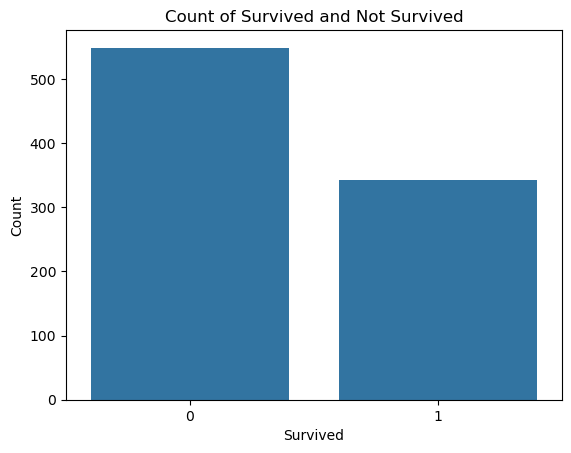

In [19]:
# countplot function is used for the simple to show the verticval bar plot for the categorical columns and the x axis is the categorical column and the y axis is the count of the categorical column and the data is the datasets and then i will show the plot using the show method

sns.countplot(x="Survived", data=df)
plt.title("Count of Survived and Not Survived")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

In [20]:
# the key learns from the visualization  is that the number of passengers who did not survive is more than the number of passengers who survived and this is a very important insight that we can use in our analysis and in our model building process because we can use this insight to balance the datasets by using the oversampling or undersampling techniques to make the datasets more balanced and to improve the performance of our model.

### 4.2 GENDER DISTRIBUTION

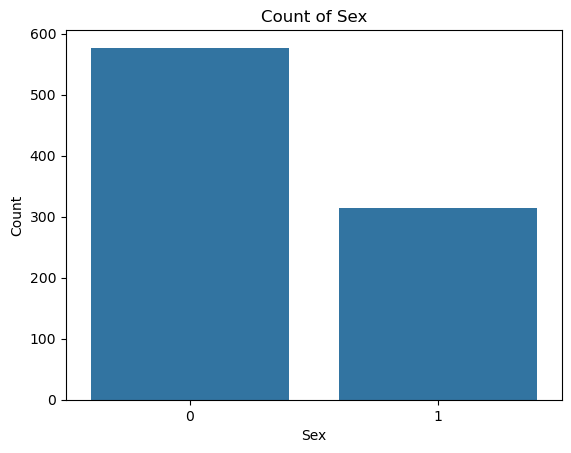

In [21]:
sns.countplot(x="Sex", data=df)
plt.title("Count of Sex")
plt.xlabel("Sex")   
plt.ylabel("Count")
plt.show()


In [22]:
# now this visualization shows that the number of male passengers is more than the number of female passengers and this is a very important insight that we can use in our analysis and in our model building process because we can use this insight to balance the datasets by using the oversampling or undersampling techniques to make the datasets more balanced and to improve the performance of our model.

### 4.3 PASSENGER CLASS DISTRIBUTION

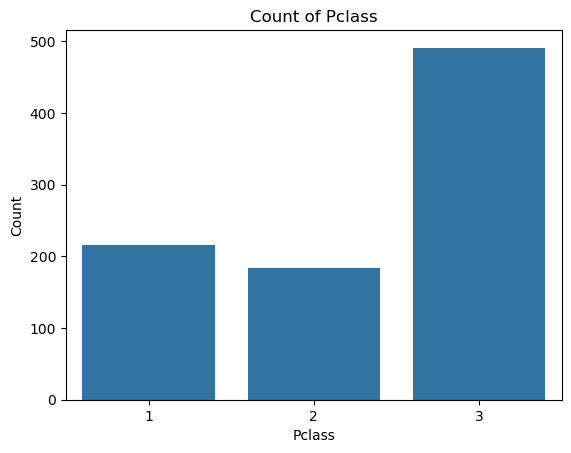

In [23]:
sns.countplot(x="Pclass", data=df)
plt.title("Count of Pclass")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.show()

In [24]:
# now there is visualize that the number of passengers in the 3rd class is more than the number of passengers in the 1st class and the 2nd class and this is a very important insight that we can use in our analysis and in our model building process because we can use this insight to balance the datasets by using the oversampling or undersampling techniques to make the datasets more balanced and to improve the performance of our model.

### 4.4 AGE DISTRIBUTION

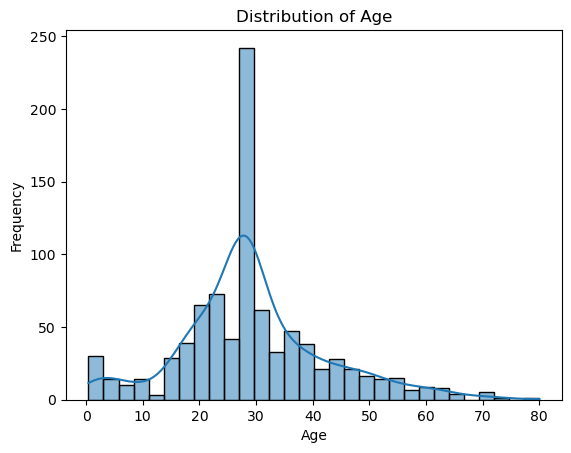

In [25]:

sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# kde=True: This stands for Kernel Density Estimate. It adds that smooth, curvy line over the bars. It helps you see the overall flow of the distribution without the jaggedness of the bars.
# bins =30: This means we are dividing the age range into 30 equal parts (or bins) to create the histogram. Each bin will count how many ages fall into that range, and the height of the bars will represent those counts.

In [26]:
# now there is used for the visualize the distribution of the age column and the key learns from this visualization is that the age distribution is right skewed which means that there are more passengers in the younger age group than in the older age group and this is a very important insight that we can use in our analysis and in our model building process because we can use this insight to balance the datasets by using the oversampling or undersampling techniques to make the datasets more balanced and to improve the performance of our model.

### 4.5 FARE DISTRIBUTION

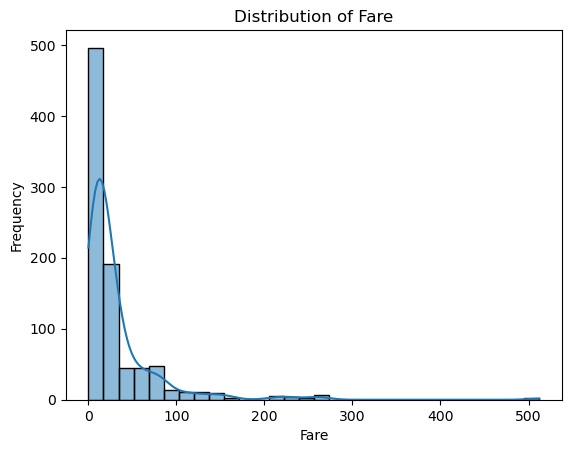

In [27]:
### 4.5 FARE DISTRIBUTION
sns.histplot(df["Fare"], bins=30, kde=True)
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

### 4.6 FAMILY FEATURES

In [28]:
# create the new feature and then we univariately visualize it 
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# means that the family size is the total number of family members that a passenger has on board the titanic and it is calculated by adding the number of siblings/spouses (SibSp) and the number of parents/children (Parch) and then adding 1 to include the passenger themselves in the count. This new feature can provide insights into how family size may have influenced survival rates on the Titanic, as passengers with larger families may have had different survival outcomes compared to those traveling alone or with smaller families.

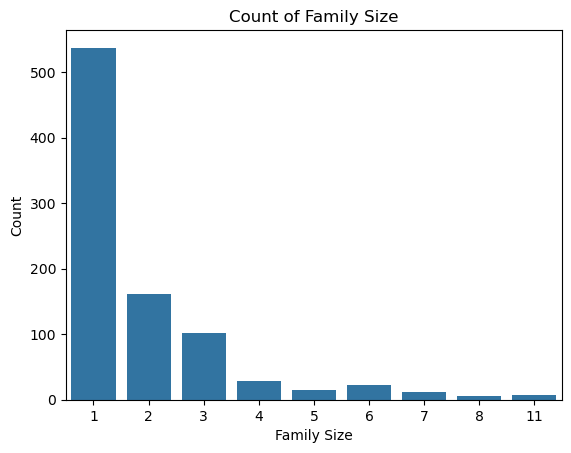

In [29]:
# now ploting 
sns.countplot(x="FamilySize", data=df)
plt.title("Count of Family Size")
plt.xlabel("Family Size")
plt.ylabel("Count")
plt.show()

In [30]:
#  this  ahowa that the family size of 1 is the most common family size among the passengers on the Titanic, which means that many passengers were traveling alone. The next most common family sizes are 2 and 3, indicating that there were also many passengers traveling with one or two family members. Larger family sizes (4 and above) are less common, suggesting that fewer passengers were traveling with larger groups of family members. This insight can be useful for understanding the demographics of the passengers and how family size may have influenced survival rates on the Titanic.

## BIVARIATE ANALYSIS (Relationship with Target)

### 5.1 SEX vs SURVIVAL

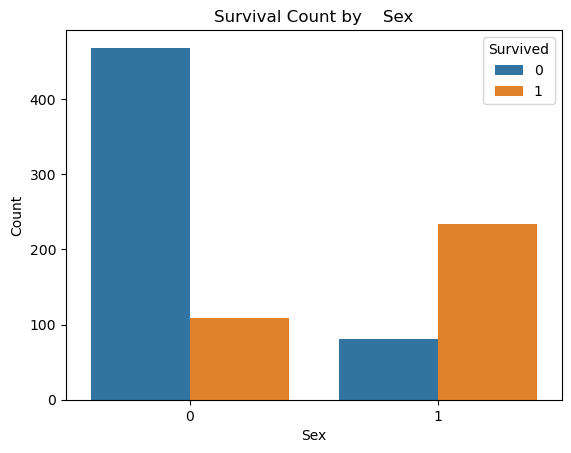

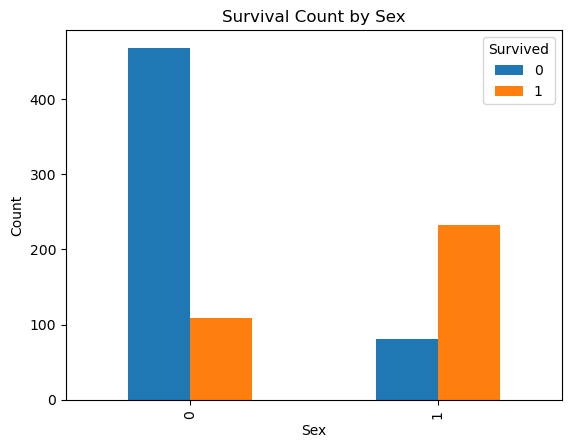

In [31]:
# compare the sex with the survival bi variate analysis
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival Count by    Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

# or alternatively we can use the crosstab function to compare the survival count by sex
pd.crosstab(df["Sex"], df["Survived"]).plot(kind="bar")
plt.title("Survival Count by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

In [32]:
# these show that the number of male passengers who did not survive is more than the number of male passengers who survived and the number of female passengers who survived is more than the number of female passengers who did not survive and this is a very important insight that we can use in our analysis and in our model building process because we can use this insight to balance the datasets by using the oversampling or undersampling techniques to make the datasets more balanced and to improve the performance of our model.

### 5.2 PASSENGER CLASS vs SURVIVAL

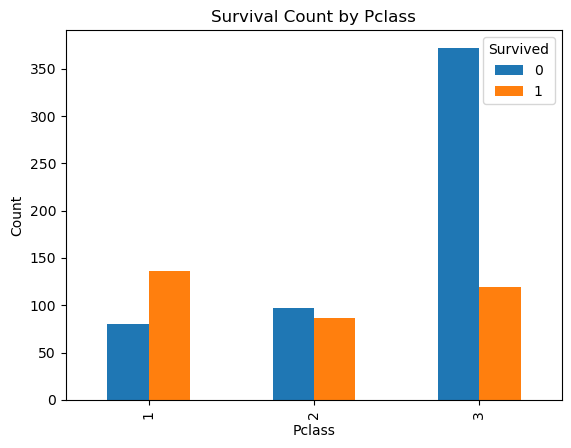

In [33]:
pd.crosstab(df["Pclass"], df["Survived"]).plot(kind="bar")
plt.title("Survival Count by Pclass")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.show()

In [34]:
# these show that the number of passengers in the 3rd class who did not survive is more than the number of passengers in the 3rd class who survived and the number of passengers in the 1st class who survived is more than the number of passengers in the 1st class who did not survive and this is a very important insight that we can use in our analysis and in our model building process because we can use this insight to balance the datasets by using the oversampling or undersampling techniques to make the datasets more balanced and to improve the performance of our model.

### 5.3 AGE vs SURVIVAL

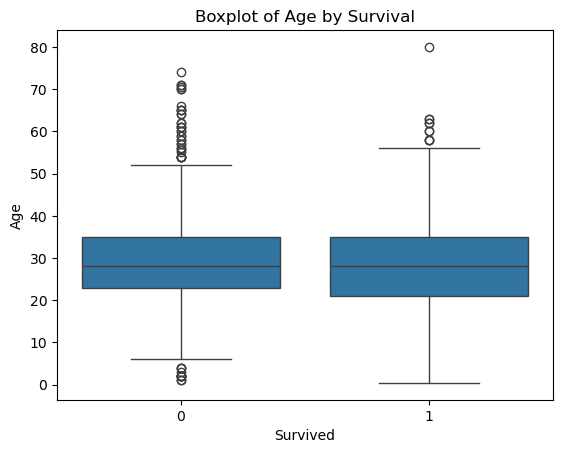

In [35]:
sns.boxplot(x="Survived", y="Age", data=df)
plt.title("Boxplot of Age by Survival")
plt.xlabel("Survived")
plt.ylabel("Age")
plt.show()

In [ ]:
# these show that the median age of passengers who survived is lower than the median age of passengers who did not survive, indicating that younger passengers had a higher survival rate compared to older passengers. Additionally, the interquartile range (IQR) for survivors is narrower than that of non-survivors, suggesting that the ages of survivors were more concentrated around the median, while non-survivors had a wider age distribution. This insight can be useful for understanding how age may have influenced survival rates on the Titanic and can be considered in our analysis and model building process.

### 5.4 FARE vs SURVIVAL

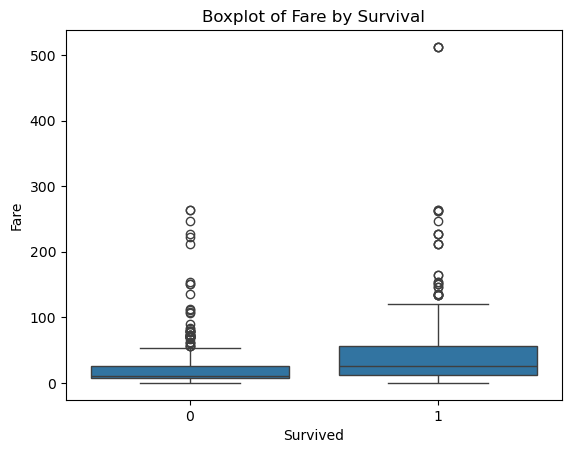

In [37]:
sns.boxplot(x="Survived", y="Fare", data=df)
plt.title("Boxplot of Fare by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()

In [ ]:
# these show that the median fare paid by passengers who survived is higher than the median fare paid by passengers who did not survive, indicating that passengers who paid higher fares had a higher survival rate compared to those who paid lower fares. Additionally, the interquartile range (IQR) for survivors is wider than that of non-survivors, suggesting that the fares paid by survivors were more varied, while non-survivors had a narrower range of fares. This insight can be useful for understanding how fare may have influenced survival rates on the Titanic and can be considered in our analysis and model building process.

### 5.5 FAMILY SIZE vs SURVIVAL

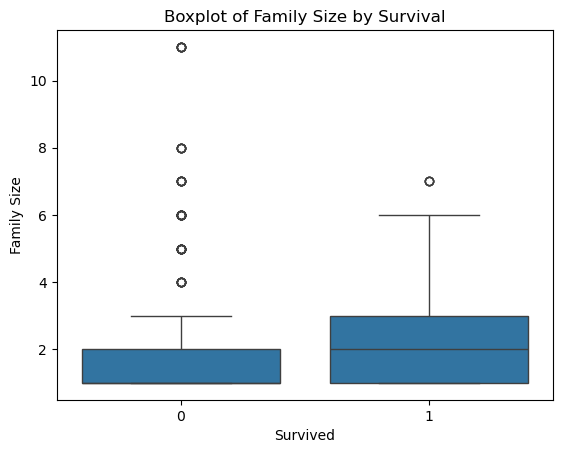

In [39]:
sns.boxplot(x="Survived", y="FamilySize", data=df)
plt.title("Boxplot of Family Size by Survival")
plt.xlabel("Survived")
plt.ylabel("Family Size")
plt.show()

In [ ]:
# these show that the family size of passengers who survived is smaller than the family size of passengers who did not survive, indicating that passengers with smaller family sizes had a higher survival rate compared to those with larger family sizes. Additionally, the interquartile range (IQR) for survivors is narrower than that of non-survivors, suggesting that the family sizes of survivors were more concentrated around the median, while non-survivors had a wider range of family sizes. This insight can be useful for understanding how family size may have influenced survival rates on the Titanic and can be considered in our analysis and model building process.

## 6.1 CORRELATION HEATMAP

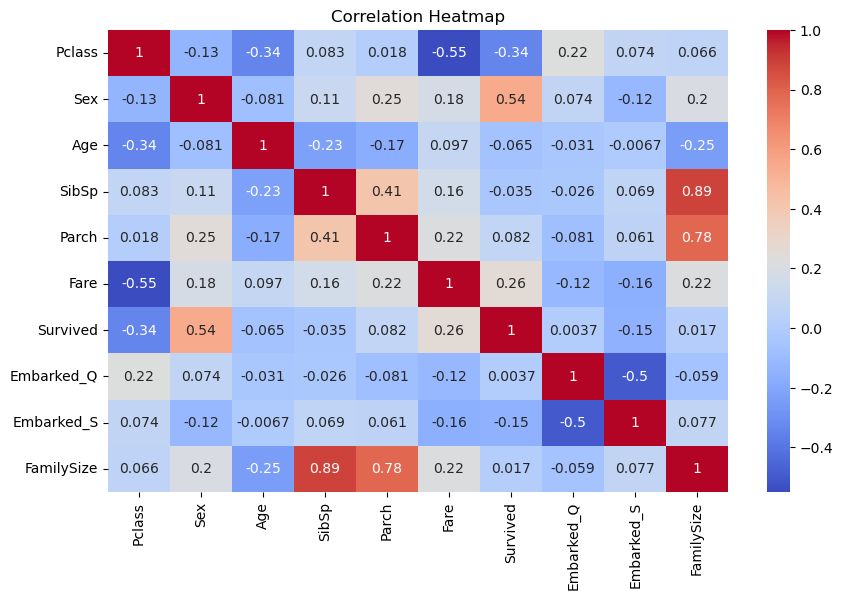

In [40]:
# thesr is the multiple relation that shows the relationship between the age, fare and family size with the survival of the passengers on the Titanic and it can be used to understand how these features may have influenced survival rates and can be considered in our analysis and model building process.
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# the heatmap shows that the Survived column has a positive correlation with the Sex column, which indicates that female passengers had a higher survival rate compared to male passengers. Additionally, the Survived column has a positive correlation with the Pclass column, which suggests that passengers in higher classes had a higher survival rate compared to those in lower classes. The Survived column also has a positive correlation with the Fare column, indicating that passengers who paid higher fares had a higher survival rate. Lastly, the Survived column has a negative correlation with the Age column, suggesting that younger passengers had a higher survival rate compared to older passengers. These insights can be useful for understanding how different features may have influenced survival rates on the Titanic and can be considered in our analysis and model building process.

# STEP 7: FINAL INSIGHTS + CONCLUSION

## 7.1 KEY INSIGHTS

**📌 Key Findings**
#### Gender was the most significant factor affecting survival. Female passengers had a much higher survival rate compared to males.

#### Passenger class strongly influenced survival. Passengers in 1st class had the highest survival rate, while those in 3rd class had the lowest.

### Fare showed a positive relationship with survival, indicating that passengers who paid higher ticket prices were more likely to survive.

### Age had a weak influence, although younger passengers showed slightly better survival chances.

### Family size had a non-linear effect: passengers traveling in small families had better survival chances than those traveling alone or in very large groups.

### Embarked location had minimal impact on survival compared to other features.


## 7.2 CONCLUSION

This exploratory data analysis (EDA) of the Titanic dataset reveals that survival was not random but influenced by several key socio-demographic factors.

Gender and passenger class emerged as the most critical determinants, highlighting the role of social structure during the disaster. Fare also played an indirect role due to its association with class.

While age and family size showed some influence, their impact was relatively weaker.

Overall, EDA helped uncover meaningful patterns and relationships in the dataset, providing a strong foundation for building predictive machine learning models.